In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='darkgrid')
plt.rcParams['figure.figsize'] = (12, 5)

print("libraries loaded")

libraries loaded


In [73]:
# Loading the amazon ecommerce dataset
# 1 million real order records across 5 indian cities
# covers product categories, delivery status, shipping times, pricing and more

df = pd.read_csv('amazon_ecommerce_1M.csv')

# Converting purchase_date 
df['purchase_date'] = pd.to_datetime(df['purchase_date'])
df['year']          = df['purchase_date'].dt.year
df['month']         = df['purchase_date'].dt.month
df['quarter']       = df['purchase_date'].dt.quarter

# Creating a binary on_time column — 1 if delivered on time, 0 if delayed
df['on_time'] = df['delivery_status'].apply(lambda x: 1 if x == 'Delivered' else 0)

# Delay flag — 1 if the order was delayed
df['is_delayed'] = df['delivery_status'].apply(lambda x: 1 if x == 'Delayed' else 0)

print(f"Rows      : {df.shape[0]:,}")
print(f"Columns   : {df.shape[1]}")
print(f"Date Range: {df['purchase_date'].min().date()} - {df['purchase_date'].max().date()}")
print()
df.head()

Rows      : 1,000,000
Columns   : 25
Date Range: 2024-03-31 - 2026-03-31



,user_id,product_id,category,subcategory,brand,price,discount,final_price,rating,review_count,...,location,device,payment_method,is_returned,delivery_status,year,month,quarter,on_time,is_delayed
0,U356787,P39256,Electronics,Mobile,H&M,33090.51,10.46,29629.31,4.9,43,...,Bangalore,Tablet,UPI,True,Returned,2025,3,1,0,0
1,U198246,P38657,Sports,Outdoor,Samsung,9368.97,5.32,8870.73,3.9,13,...,Delhi,Tablet,UPI,True,Returned,2025,12,4,0,0
2,U539898,P38893,Sports,Fitness,H&M,14756.85,26.00,10919.43,4.2,46,...,Chennai,Mobile App,Credit Card,True,Returned,2024,4,2,0,0
3,U325772,P54118,Beauty,Makeup,Sony,668.83,24.81,502.91,3.8,6,...,Mumbai,Web,UPI,False,In Transit,2025,12,4,0,0
4,U865179,P70217,Home,Decor,Sony,10881.29,48.63,5589.58,4.0,48,...,Delhi,Web,UPI,False,Delayed,2024,5,2,0,1


In [75]:
# Checking data quality before doing any analysis

print("Missing Values:")
print(df.isnull().sum())

print(f"\nDuplicates: {df.duplicated().sum()}")

print("\nDelivery Status Breakdown:")
print(df['delivery_status'].value_counts())

print("\nCategory Breakdown:")
print(df['category'].value_counts())

print("\nLocation Breakdown:")
print(df['location'].value_counts())

print("\nDescriptive Statistics:")
display(df[['price', 'discount', 'final_price', 'shipping_time_days',
            'rating', 'seller_rating']].describe().round(2))

Missing Values:
user_id               0
product_id            0
category              0
subcategory           0
brand                 0
price                 0
discount              0
final_price           0
rating                0
review_count          0
stock                 0
seller_id             0
seller_rating         0
purchase_date         0
shipping_time_days    0
location              0
device                0
payment_method        0
is_returned           0
delivery_status       0
year                  0
month                 0
quarter               0
on_time               0
is_delayed            0
dtype: int64

Duplicates: 0

Delivery Status Breakdown:
delivery_status
Delivered     295234
Delayed       294983
In Transit    293793
Returned      115990
Name: count, dtype: int64

Category Breakdown:
category
Home           200922
Electronics    200038
Sports         199889
Clothing       199824
Beauty         199327
Name: count, dtype: int64

Location Breakdown:
location
Delhi 

,price,discount,final_price,shipping_time_days,rating,seller_rating
count,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00,1000000.00
mean,13224.12,29.00,9938.88,3.17,3.93,3.75
std,18079.63,14.68,14271.89,1.67,0.52,0.72
min,200.03,5.00,101.46,1.00,1.50,2.50
25%,2700.15,16.91,1705.93,2.00,3.60,3.10
50%,4971.83,28.07,3790.80,3.00,3.90,3.80
75%,14134.48,39.24,10384.44,5.00,4.30,4.40
max,79999.70,70.00,75831.11,6.00,5.00,5.00


In [77]:
# Calculating the core delivery performance metrics

total           = len(df)
delivered_rate  = (df['delivery_status'] == 'Delivered').mean() * 100
delayed_rate    = (df['delivery_status'] == 'Delayed').mean() * 100
in_transit_rate = (df['delivery_status'] == 'In Transit').mean() * 100
returned_rate   = (df['delivery_status'] == 'Returned').mean() * 100
avg_ship_time   = df['shipping_time_days'].mean()
avg_price       = df['final_price'].mean()
avg_discount    = df['discount'].mean()
avg_rating      = df['rating'].mean()
return_count    = df['is_returned'].sum()

print("=" * 55)
print("  DELIVERY PERFORMANCE KPI SUMMARY")
print("=" * 55)
print(f"Total Orders          : {total:,}")
print(f"Successfully Delivered: {delivered_rate:.1f}%")
print(f"Delayed Orders        : {delayed_rate:.1f}%")
print(f"In Transit            : {in_transit_rate:.1f}%")
print(f"Returned Orders       : {returned_rate:.1f}%")
print(f"Avg Shipping Time     : {avg_ship_time:.1f} days")
print(f"Avg Order Value       : ₹{avg_price:,.2f}")
print(f"Avg Discount Applied  : {avg_discount:.1f}%")
print(f"Avg Customer Rating   : {avg_rating:.2f} / 5.0")
print(f"Total Returns         : {return_count:,}")
print("=" * 55)

  DELIVERY PERFORMANCE KPI SUMMARY
Total Orders          : 1,000,000
Successfully Delivered: 29.5%
Delayed Orders        : 29.5%
In Transit            : 29.4%
Returned Orders       : 11.6%
Avg Shipping Time     : 3.2 days
Avg Order Value       : ₹9,938.88
Avg Discount Applied  : 29.0%
Avg Customer Rating   : 3.93 / 5.0
Total Returns         : 115,990


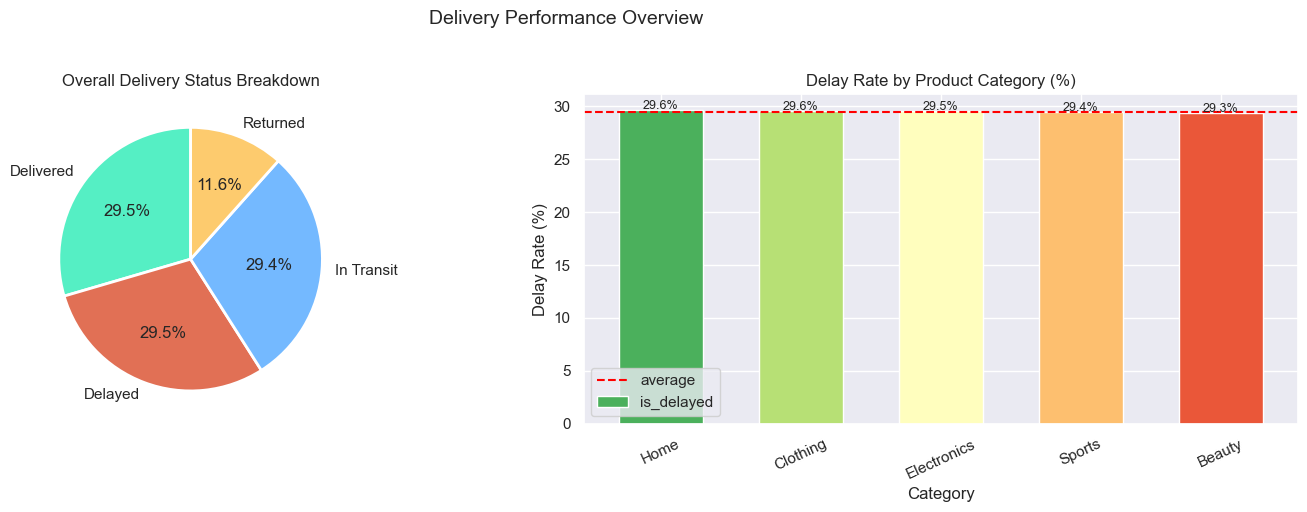

In [79]:
# Looking at how delivery performance differs across product categories

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Delivery status overall
status_counts = df['delivery_status'].value_counts()
colors_status = ['#55efc4', '#e17055', '#74b9ff', '#fdcb6e']
axes[0].pie(status_counts, labels=status_counts.index,
            colors=colors_status, autopct='%1.1f%%',
            startangle=90, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[0].set_title('Overall Delivery Status Breakdown')

# Delay rate by category
cat_delay = df.groupby('category')['is_delayed'].mean() * 100
cat_delay = cat_delay.sort_values(ascending=False)
cat_delay.plot(kind='bar', ax=axes[1],
               color=sns.color_palette('RdYlGn_r', len(cat_delay)),
               edgecolor='white', width=0.6)
axes[1].set_title('Delay Rate by Product Category (%)')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Delay Rate (%)')
axes[1].tick_params(axis='x', rotation=25)
axes[1].axhline(y=delayed_rate, color='red', linestyle='--', label='average')
axes[1].legend()
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.1),
                     ha='center', fontsize=9)

plt.suptitle('Delivery Performance Overview', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig1_delivery_overview.png', dpi=150, bbox_inches='tight')
plt.show()

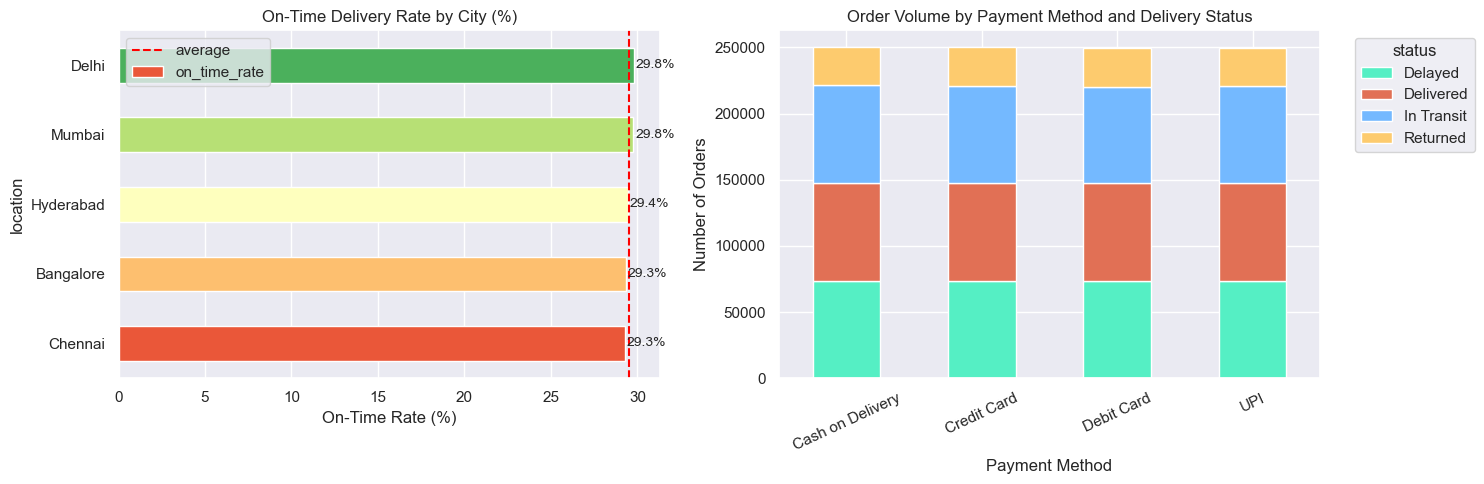

City Performance Summary:


,on_time_rate,avg_ship_days,total_orders
location,,,
Chennai,29.279347,3.506523,199902
Bangalore,29.322415,3.500974,200270
Hyderabad,29.429768,3.495336,199305
Mumbai,29.766753,2.669277,199874
Delhi,29.817741,2.662017,200649


In [81]:
# Comparing delivery performance across the 5 cities

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# On-time rate by city
city_perf = df.groupby('location').agg(
    on_time_rate = ('on_time', lambda x: x.mean() * 100),
    avg_ship_days = ('shipping_time_days', 'mean'),
    total_orders = ('on_time', 'count')
).sort_values('on_time_rate', ascending=True)

city_perf['on_time_rate'].plot(kind='barh', ax=axes[0],
    color=sns.color_palette('RdYlGn', len(city_perf)), edgecolor='white')
axes[0].set_title('On-Time Delivery Rate by City (%)')
axes[0].set_xlabel('On-Time Rate (%)')
axes[0].axvline(x=delivered_rate, color='red', linestyle='--', label='average')
axes[0].legend()
for i, v in enumerate(city_perf['on_time_rate']):
    axes[0].text(v + 0.1, i, f'{v:.1f}%', va='center', fontsize=10)

# Delivery status by payment method
payment_status = df.groupby(['payment_method', 'delivery_status'])\
                   ['on_time'].count().unstack(fill_value=0)
payment_status.plot(kind='bar', ax=axes[1], stacked=True,
    color=['#55efc4', '#e17055', '#74b9ff', '#fdcb6e'], edgecolor='white')
axes[1].set_title('Order Volume by Payment Method and Delivery Status')
axes[1].set_xlabel('Payment Method')
axes[1].set_ylabel('Number of Orders')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(title='status', bbox_to_anchor=(1.05, 1))

plt.tight_layout()
plt.savefig('fig2_city_payment.png', dpi=150, bbox_inches='tight')
plt.show()

print("City Performance Summary:")
display(city_perf)

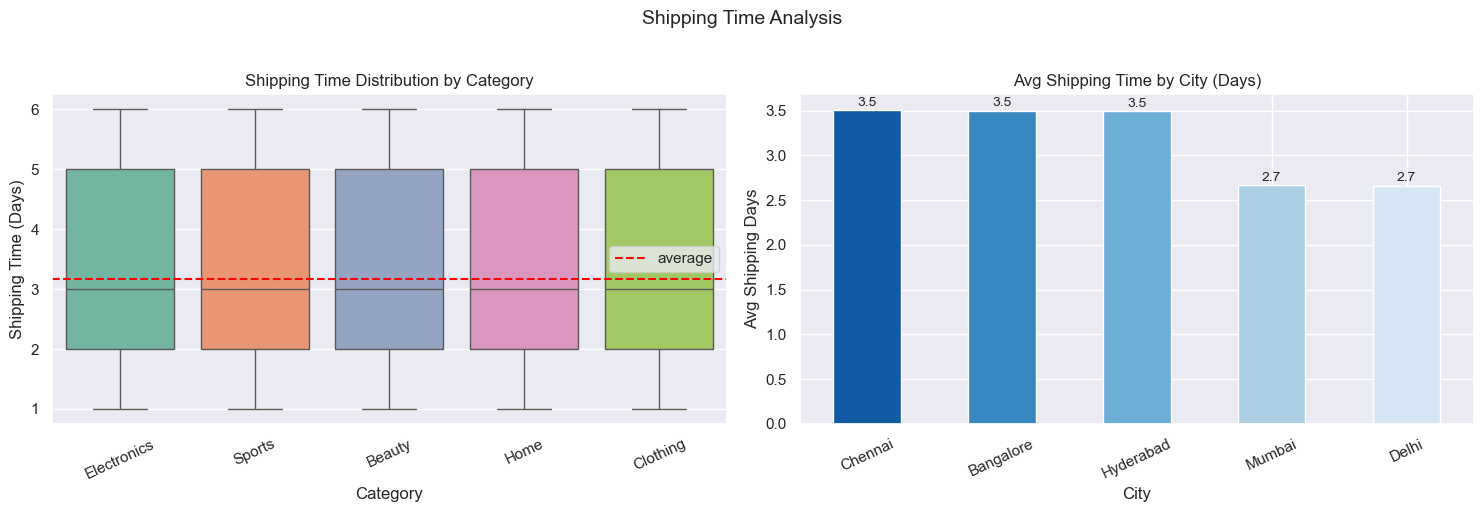

In [83]:
# Looking at how shipping time varies across categories, cities, and over time

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Shipping time distribution by category
sns.boxplot(data=df, x='category', y='shipping_time_days',
            palette='Set2', ax=axes[0])
axes[0].set_title('Shipping Time Distribution by Category')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Shipping Time (Days)')
axes[0].tick_params(axis='x', rotation=25)
axes[0].axhline(y=avg_ship_time, color='red', linestyle='--', label='average')
axes[0].legend()

# Avg shipping time by city
city_ship = df.groupby('location')['shipping_time_days'].mean().sort_values(ascending=False)
city_ship.plot(kind='bar', ax=axes[1],
               color=sns.color_palette('Blues_r', len(city_ship)), edgecolor='white')
axes[1].set_title('Avg Shipping Time by City (Days)')
axes[1].set_xlabel('City')
axes[1].set_ylabel('Avg Shipping Days')
axes[1].tick_params(axis='x', rotation=25)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}',
                     (p.get_x() + p.get_width()/2, p.get_height() + 0.05),
                     ha='center', fontsize=10)

plt.suptitle('Shipping Time Analysis', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig3_shipping_time.png', dpi=150, bbox_inches='tight')
plt.show()

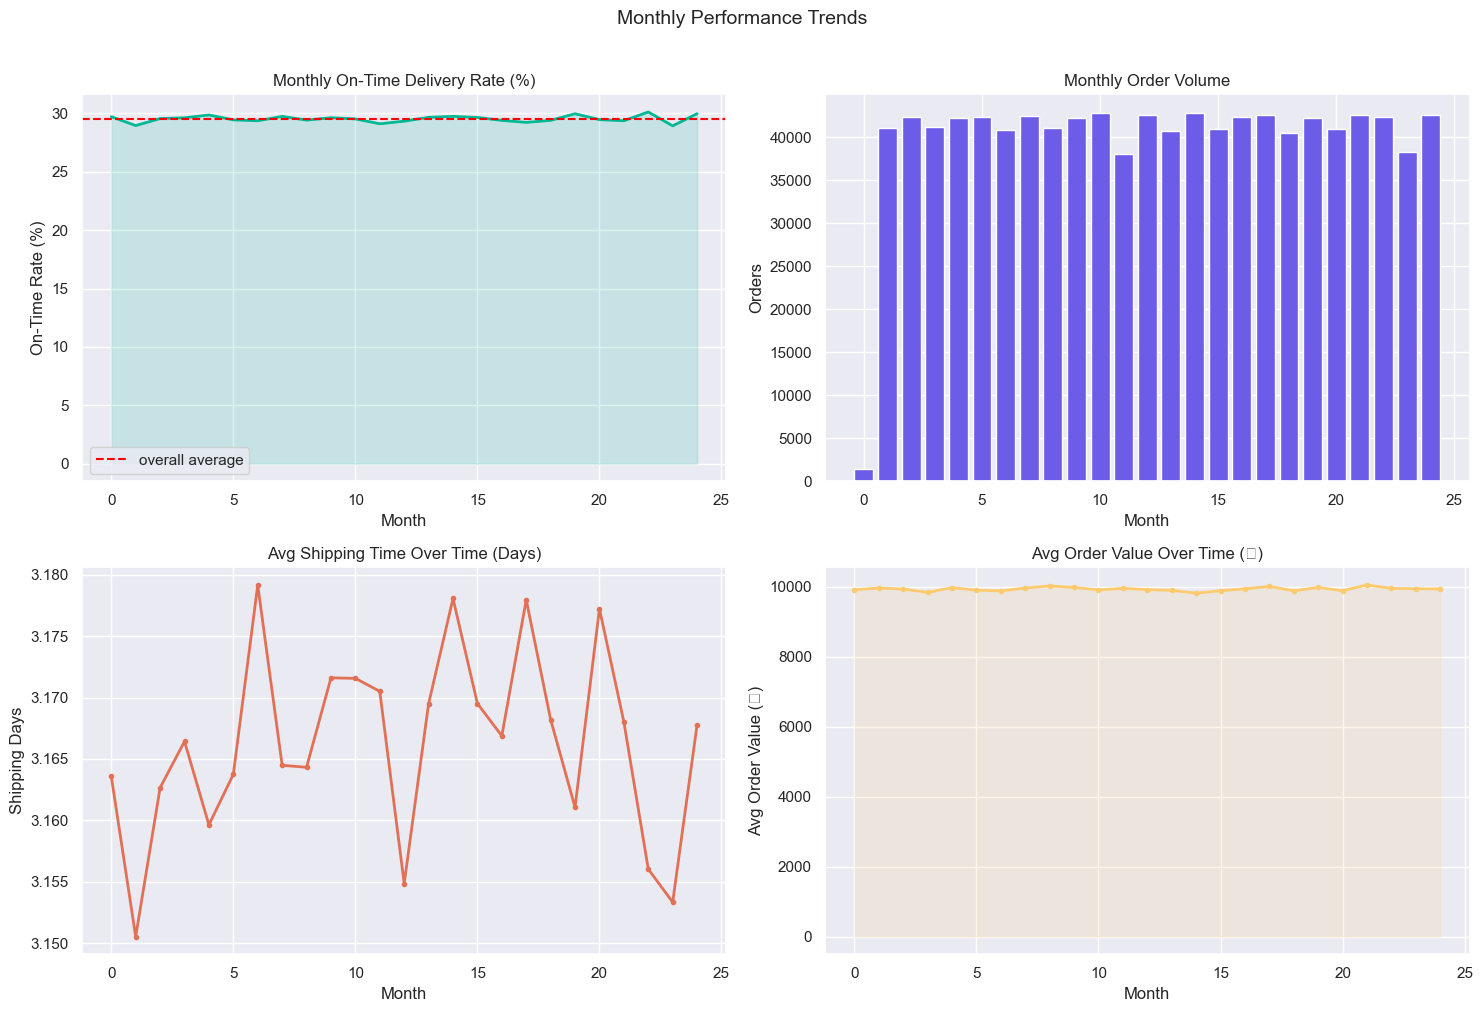

In [85]:
# Tracking how delivery performance and order volume changed over time
# Useful for identifying seasonal patterns or operational improvements

monthly = df.groupby(['year', 'month']).agg(
    on_time_rate  = ('on_time', lambda x: x.mean() * 100),
    avg_ship_days = ('shipping_time_days', 'mean'),
    order_volume  = ('on_time', 'count'),
    avg_order_val = ('final_price', 'mean')
).reset_index()

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# On-time rate trend
axes[0,0].plot(range(len(monthly)), monthly['on_time_rate'],
               color='#00b894', linewidth=2)
axes[0,0].fill_between(range(len(monthly)), monthly['on_time_rate'],
                        alpha=0.15, color='#00b894')
axes[0,0].set_title('Monthly On-Time Delivery Rate (%)')
axes[0,0].set_ylabel('On-Time Rate (%)')
axes[0,0].set_xlabel('Month')
axes[0,0].axhline(y=delivered_rate, color='red', linestyle='--', label='overall average')
axes[0,0].legend()

# Order volume
axes[0,1].bar(range(len(monthly)), monthly['order_volume'],
              color='#6c5ce7', edgecolor='white', width=0.8)
axes[0,1].set_title('Monthly Order Volume')
axes[0,1].set_ylabel('Orders')
axes[0,1].set_xlabel('Month')

# Avg shipping days trend
axes[1,0].plot(range(len(monthly)), monthly['avg_ship_days'],
               color='#e17055', linewidth=2, marker='o', markersize=3)
axes[1,0].set_title('Avg Shipping Time Over Time (Days)')
axes[1,0].set_ylabel('Shipping Days')
axes[1,0].set_xlabel('Month')

# Avg order value trend
axes[1,1].plot(range(len(monthly)), monthly['avg_order_val'],
               color='#fdcb6e', linewidth=2, marker='o', markersize=3)
axes[1,1].fill_between(range(len(monthly)), monthly['avg_order_val'],
                        alpha=0.15, color='#fdcb6e')
axes[1,1].set_title('Avg Order Value Over Time (₹)')
axes[1,1].set_ylabel('Avg Order Value (₹)')
axes[1,1].set_xlabel('Month')

plt.suptitle('Monthly Performance Trends', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('fig4_trends.png', dpi=150, bbox_inches='tight')
plt.show()

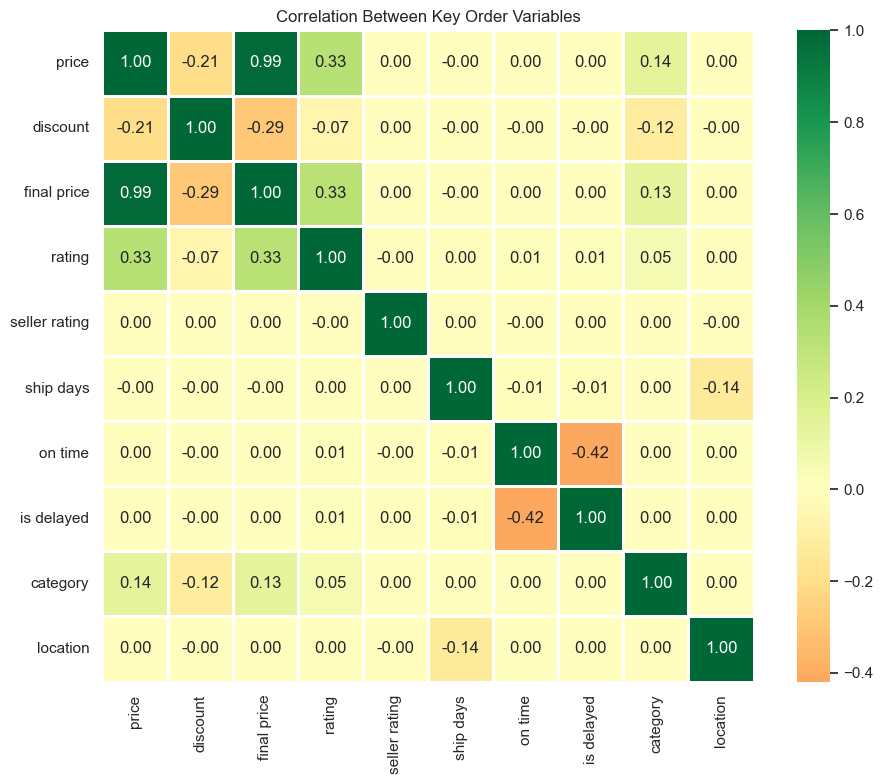

On_time and is_delayed are perfectly negatively correlated as expected
Seller rating has a small positive effect on on-time delivery


In [89]:
# Checking how all numeric variables relate to each other
# Helps identify which features are useful for the prediction model

df_corr = df.copy()
le_temp = LabelEncoder()
for col in ['category', 'location', 'device', 'payment_method', 'delivery_status']:
    df_corr[col + '_enc'] = le_temp.fit_transform(df_corr[col])

corr_cols = [
    'price', 'discount', 'final_price', 'rating',
    'seller_rating', 'shipping_time_days', 'on_time',
    'is_delayed', 'category_enc', 'location_enc'
]

corr = df_corr[corr_cols].corr()

corr.columns = ['price', 'discount', 'final price', 'rating',
                'seller rating', 'ship days', 'on time',
                'is delayed', 'category', 'location']
corr.index = corr.columns

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            center=0, linewidths=0.8, square=True)
plt.title('Correlation Between Key Order Variables')
plt.tight_layout()
plt.savefig('fig5_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print("On_time and is_delayed are perfectly negatively correlated as expected")
print("Seller rating has a small positive effect on on-time delivery")

In [67]:
# Predicting Whether An Order Will Be Returned
# This Is More Meaningful Than Shipping Time For This Dataset

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix, roc_curve)

df_ml = df.copy()
le = LabelEncoder()
for col in ['category', 'location', 'device', 'payment_method']:
    df_ml[col + '_enc'] = le.fit_transform(df_ml[col])

features = [
    'price', 'discount', 'final_price', 'rating',
    'seller_rating', 'year', 'month', 'quarter',
    'category_enc', 'location_enc', 'device_enc', 'payment_method_enc'
]
target = 'is_returned'

X = df_ml[features]
y = df_ml[target]

X_sample, _, y_sample, _ = train_test_split(X, y, train_size=100000, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42
)

print(f"Training On {X_train.shape[0]:,} Orders")
print(f"Testing On  {X_test.shape[0]:,} Orders\n")

models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Decision Tree':       DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    probs = model.predict_proba(X_test)[:, 1]

    acc  = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds)
    rec  = recall_score(y_test, preds)
    f1   = f1_score(y_test, preds)
    auc  = roc_auc_score(y_test, probs)
    cv   = cross_val_score(model, X_sample, y_sample, cv=3, scoring='roc_auc').mean()

    results.append({
        'model':         name,
        'accuracy':      round(acc, 4),
        'precision':     round(prec, 4),
        'recall':        round(rec, 4),
        'f1':            round(f1, 4),
        'auc':           round(auc, 4),
        'cv_auc':        round(cv, 4)
    })
    print(f"{name:<22}  Acc={acc:.4f}  AUC={auc:.4f}  Recall={rec:.4f}  CV={cv:.4f}")

results_df = pd.DataFrame(results)
print()
display(results_df)

Training On 80,000 Orders
Testing On  20,000 Orders

Logistic Regression     Acc=0.8829  AUC=0.5409  Recall=0.0000  CV=0.5322
Decision Tree           Acc=0.8805  AUC=0.5367  Recall=0.0111  CV=0.5264
Random Forest           Acc=0.8828  AUC=0.5370  Recall=0.0030  CV=0.5312



,model,accuracy,precision,recall,f1,auc,cv_auc
0,Logistic Regression,0.8829,0.0000,0.0000,0.0000,0.5409,0.5322
1,Decision Tree,0.8805,0.2626,0.0111,0.0213,0.5367,0.5264
2,Random Forest,0.8828,0.4375,0.0030,0.0059,0.5370,0.5312


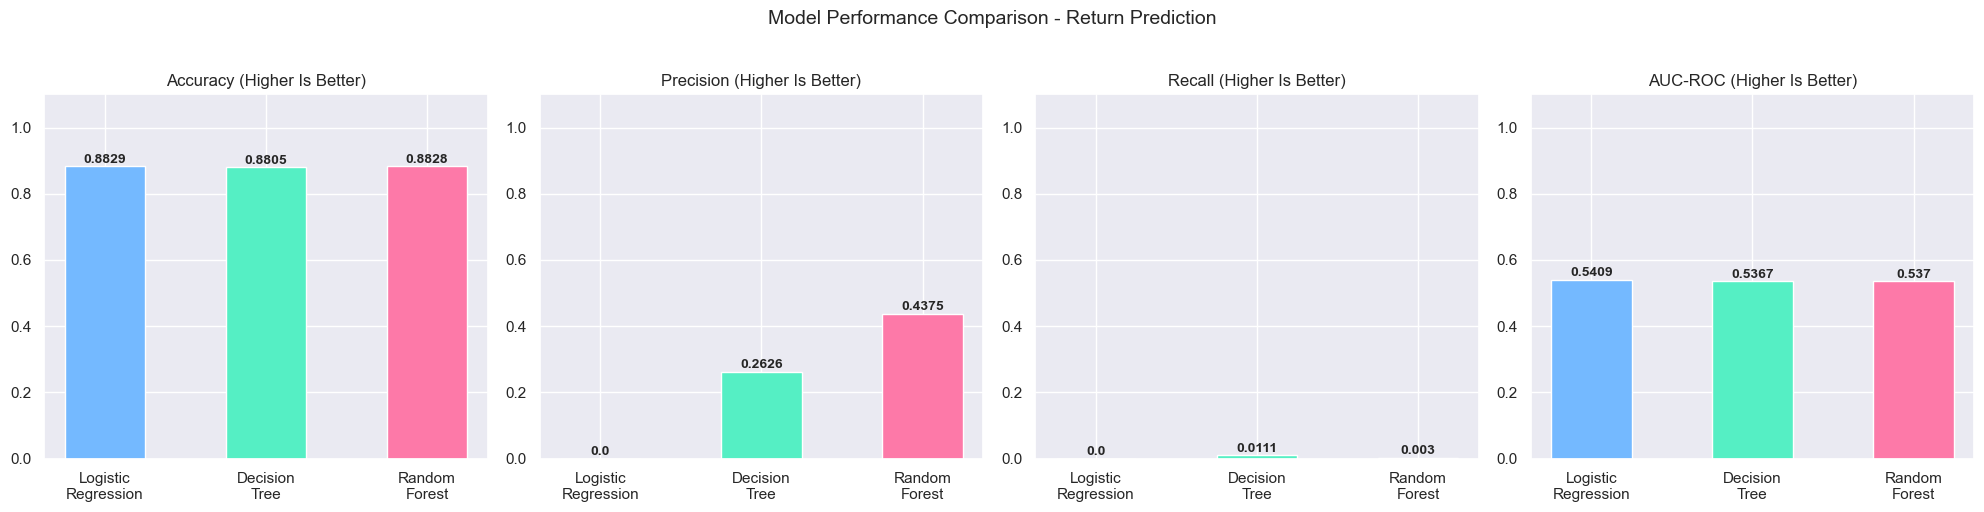

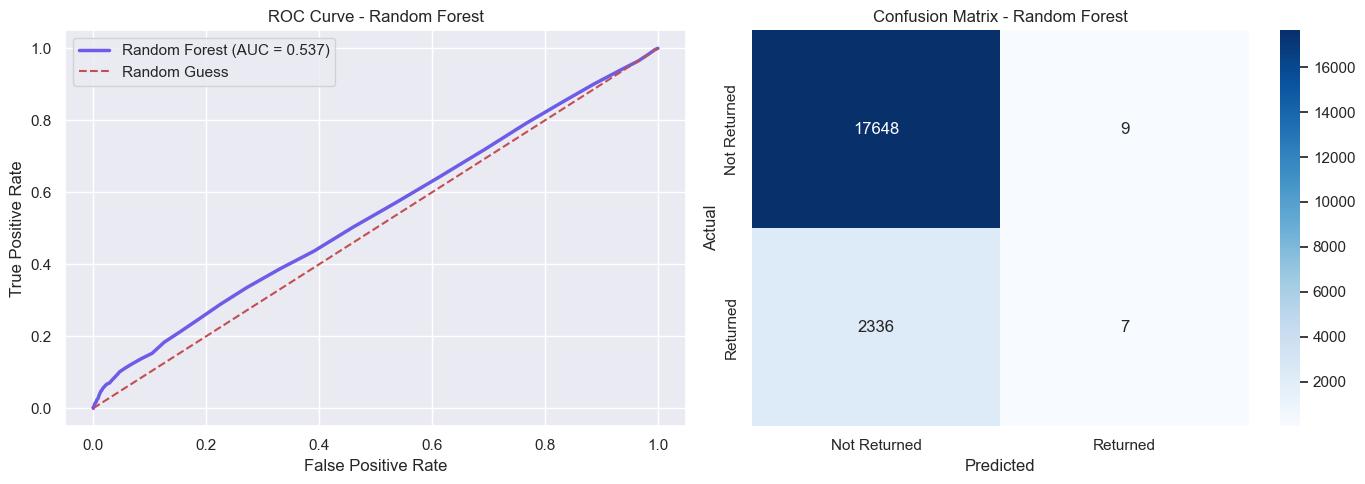

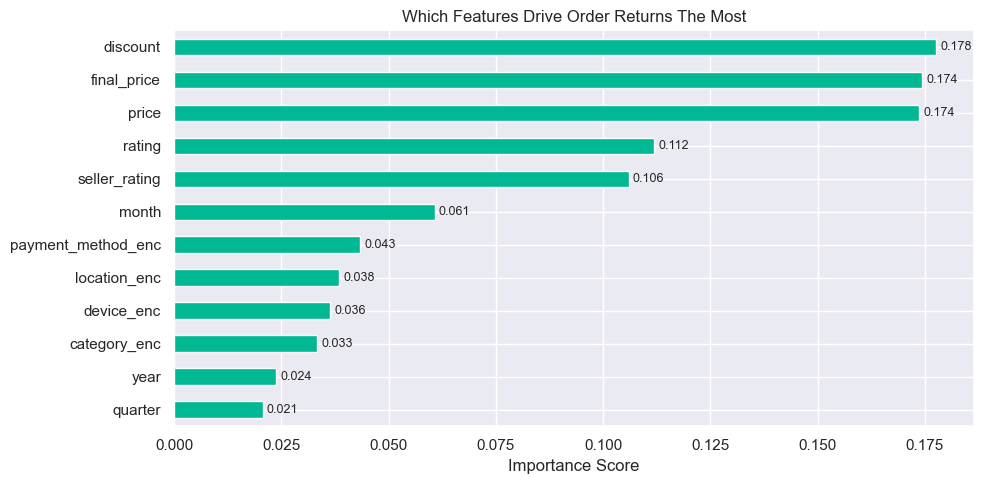

In [69]:
# Comparing All Three Models Visually
# Then ROC Curve And Confusion Matrix For The Best One

model_names = ['Logistic\nRegression', 'Decision\nTree', 'Random\nForest']
colors      = ['#74b9ff', '#55efc4', '#fd79a8']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))

for i, (col, title) in enumerate([
    ('accuracy',  'Accuracy (Higher Is Better)'),
    ('precision', 'Precision (Higher Is Better)'),
    ('recall',    'Recall (Higher Is Better)'),
    ('auc',       'AUC-ROC (Higher Is Better)')
]):
    bars = axes[i].bar(model_names, results_df[col],
                       color=colors, edgecolor='white', width=0.5)
    axes[i].set_title(title)
    axes[i].set_ylim(0, 1.1)
    for bar, val in zip(bars, results_df[col]):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.01,
                     str(val), ha='center', fontweight='bold', fontsize=10)

plt.suptitle('Model Performance Comparison - Return Prediction', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('fig6_model_scores.png', dpi=150, bbox_inches='tight')
plt.show()

# ROC Curve And Confusion Matrix For Random Forest
best_model = models['Random Forest']
preds_best = best_model.predict(X_test)
probs_best = best_model.predict_proba(X_test)[:, 1]
fpr, tpr, _ = roc_curve(y_test, probs_best)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, color='#6c5ce7', linewidth=2.5,
             label=f'Random Forest (AUC = {roc_auc_score(y_test, probs_best):.3f})')
axes[0].plot([0, 1], [0, 1], 'r--', linewidth=1.5, label='Random Guess')
axes[0].set_title('ROC Curve - Random Forest')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].legend()

cm = confusion_matrix(y_test, preds_best)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Not Returned', 'Returned'],
            yticklabels=['Not Returned', 'Returned'])
axes[1].set_title('Confusion Matrix - Random Forest')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.savefig('fig7_roc_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

# Feature Importance
importances = pd.Series(best_model.feature_importances_, index=features).sort_values()
plt.figure(figsize=(10, 5))
importances.plot(kind='barh', color='#00b894', edgecolor='white')
plt.title('Which Features Drive Order Returns The Most')
plt.xlabel('Importance Score')
for i, v in enumerate(importances.values):
    plt.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('fig8_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

In [71]:
best         = results_df.sort_values('auc', ascending=False).iloc[0]
best_city    = city_perf['on_time_rate'].idxmax()
worst_city   = city_perf['on_time_rate'].idxmin()
worst_cat    = cat_delay.idxmax()
best_cat     = cat_delay.idxmin()
fastest_city = df.groupby('location')['shipping_time_days'].mean().idxmin()

print("=" * 60)
print("  LOGISTICS & DELIVERY PERFORMANCE ANALYSIS")
print("  Data Source: Amazon Ecommerce Dataset (1M Orders)")
print("=" * 60)
print(f"""
Dataset:
  Total Orders   : {total:,}
  Date Range     : {df['purchase_date'].min().date()} - {df['purchase_date'].max().date()}
  Cities         : {df['location'].nunique()}
  Categories     : {df['category'].nunique()}
  Payment Types  : {df['payment_method'].nunique()}

Key Performance Indicators:
  Delivered Rate  : {delivered_rate:.1f}%
  Delayed Rate    : {delayed_rate:.1f}%
  In Transit      : {in_transit_rate:.1f}%
  Returned Rate   : {returned_rate:.1f}%
  Avg Ship Time   : {avg_ship_time:.1f} Days
  Avg Order Value : Rs.{avg_price:,.2f}
  Avg Discount    : {avg_discount:.1f}%
  Avg Rating      : {avg_rating:.2f} / 5.0
  Total Returns   : {return_count:,}

Key Findings:
  Best Performing City   : {best_city}
  Worst Performing City  : {worst_city}
  Fastest Shipping City  : {fastest_city}
  Most Delayed Category  : {worst_cat}
  Least Delayed Category : {best_cat}

Best Model: {best['model']}
  Accuracy      : {best['accuracy']} ({best['accuracy']*100:.1f}%)
  Precision     : {best['precision']}
  Recall        : {best['recall']}
  F1 Score      : {best['f1']}
  AUC-ROC       : {best['auc']}
  Cross Val AUC : {best['cv_auc']}

Recommendations:
  1. Investigate Delivery Operations In {worst_city} - Lowest On-Time Rate
  2. Review Fulfilment Process For {worst_cat} - Highest Delay Rate
  3. Expand Fulfilment Capacity In {fastest_city} - Benchmark For Other Cities
  4. Deploy The Return Prediction Model To Flag High-Risk Orders Before Dispatch
  5. High Return Rate Of {returned_rate:.1f}% Suggests Product Quality Or
     Description Issues Worth Investigating With The Seller Team
""")
print("=" * 60)

df.drop(columns=['purchase_date']).to_excel('amazon_logistics_clean.xlsx', index=False)



  LOGISTICS & DELIVERY PERFORMANCE ANALYSIS
  Data Source: Amazon Ecommerce Dataset (1M Orders)

Dataset:
  Total Orders   : 1,000,000
  Date Range     : 2024-03-31 - 2026-03-31
  Cities         : 5
  Categories     : 5
  Payment Types  : 4

Key Performance Indicators:
  Delivered Rate  : 29.5%
  Delayed Rate    : 29.5%
  In Transit      : 29.4%
  Returned Rate   : 11.6%
  Avg Ship Time   : 3.2 Days
  Avg Order Value : Rs.9,938.88
  Avg Discount    : 29.0%
  Avg Rating      : 3.93 / 5.0
  Total Returns   : 115,990

Key Findings:
  Best Performing City   : Delhi
  Worst Performing City  : Chennai
  Fastest Shipping City  : Delhi
  Most Delayed Category  : Home
  Least Delayed Category : Beauty

Best Model: Logistic Regression
  Accuracy      : 0.8829 (88.3%)
  Precision     : 0.0
  Recall        : 0.0
  F1 Score      : 0.0
  AUC-ROC       : 0.5409
  Cross Val AUC : 0.5322

Recommendations:
  1. Investigate Delivery Operations In Chennai - Lowest On-Time Rate
  2. Review Fulfilment Proce